# 17 · 153130 KODEX 단기채권 — Final EDA (Phase 00.5)

> 기간 2019-01-03 ~ 2026-10-02 · n=1902 일간 로그수익률 (FDR Close, 분배 소급조정 추정 · DEC-3) · UNIVERSE_STATUS=PROVISIONAL.
> 이 notebook 의 모든 수치는 `scripts/build_final_notebooks.py` 가 `src/final_figs.compute()` 로 사전계산해 적었고, 아래 코드 셀이 같은 함수로 그림을 다시 그린다.

## 왜 이런 ETF인가
| 항목 | 값 |
|---|---|
| asset_scope / category | bond / money_market |
| benchmark (상품 기초) | 단기채 (추정: KIS 통안채/단기) |
| 배율 / 환헤지 / 복제 | none / n/a (KRW) / physical |
| peer_group | KR_rates |
| 비교 기준 ① proxy | 148070 KIWOOM 국고채10년 |
| 비교 기준 ② market reference | 069500 KODEX 200 |

카드(reports/ETF_CARDS/17_153130.md) 정체성 요약:
- [OBS] asset_scope=bond · category=money_market · benchmark=단기채(추정: KIS 통안채/단기) · peer_group=KR_rates · replication=physical · confidence=low.
- [ANA] 가격이 거의 단조 증가(이자 누적)하는 현금성 ETF. 위험자산이라기보다 "현금 대용"으로 읽어야 한다.

## 핵심 수치
| ann_vol | 2026 vol | 2026 / 2019-25 | ex_kurt (trim3) | Q01 / Q99 | Max DD | β·ρ vs proxy | β·ρ vs market | |rz60|>3 (+/−) |
|---|---|---|---|---|---|---|---|---|
| 0.3% | 0.2% | 0.66× | 323.8 (6.1) | -0.02% / 0.05% | -0.5% (2024-01-30) | 0.01 · 0.100 | 0.00 · 0.046 | 39 / 22 |

정의: ann_vol=std·√252 · ex_kurt=Fisher(편향보정) · trim3=|r| 상위 3일 제거 · rz60=(r−직전60일 median)/(1.4826·직전60일 MAD), shift(1) · β/ρ=동일일 OLS·Pearson.

In [1]:
import sys
from pathlib import Path
ROOT = next(q for q in [Path.cwd(), *Path.cwd().parents] if (q / "config" / "universe.csv").exists())
sys.path.insert(0, str(ROOT))
%matplotlib inline
import pandas as pd
from src import final_figs as F
TK = "153130"
c = F.Ctx(TK)
S = F.compute(TK, c.close, c.vol, c.R)
pd.Series({k: v for k, v in S.items() if not isinstance(v, (dict, list))}).to_frame("value")

,value
ticker,153130
name,KODEX 단기채권
proxy,148070
market,069500
proxy_name,KIWOOM 국고채10년
market_name,KODEX 200
n_obs,1902
start,2019-01-03
end,2026-10-02
ann_vol,0.003244


## Fig 1. 가격(로그축)과 고점 대비 낙폭

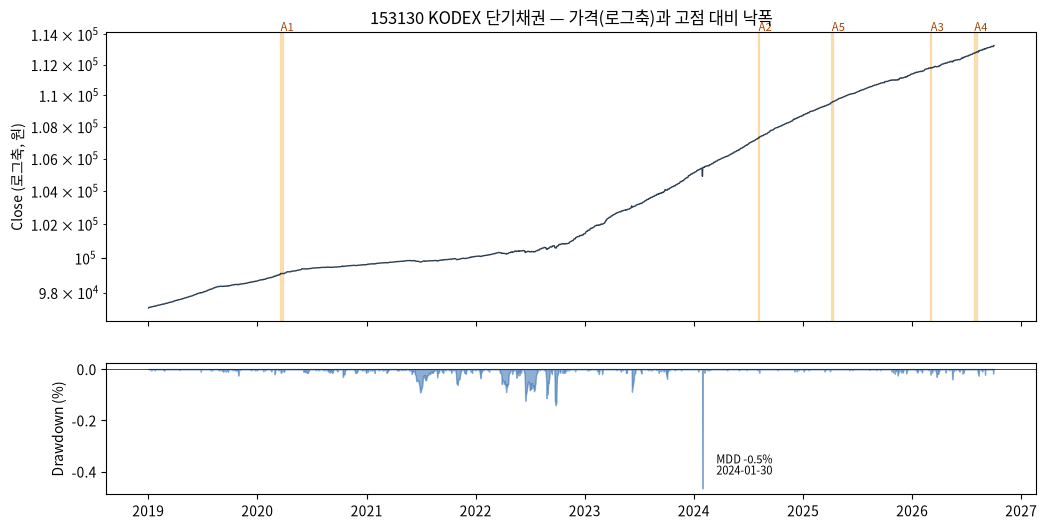

In [2]:
F.fig01_price_drawdown(c)

**WHAT THIS FIGURE MEASURES** — 위: FDR Close 로그축 (같은 높이 = 같은 % 변화). 아래: 직전 최고가 대비 낙폭 %. 주황 띠 = config/event_anchors.csv 공통충격 anchor.

**WHAT WE SEE** — 누적 로그수익률 15.4%. 최대낙폭 -0.5% (저점 2024-01-30, 고점 2024-01-29, 회복 2024-01-31). 마지막 날 낙폭 0.0%.

**WHY IT MATTERS FINANCIALLY** — 낙폭 깊이와 회복 시간은 변동성 한 숫자가 보여주지 못하는 '보유자가 실제로 겪는 손실 경로'다. 같은 변동성이라도 회복 기간이 길면 자금 회수 위험이 크다.

**WHAT WE CANNOT CONCLUDE** — 초저변동(연 0.32%) + 틱 이산성(0수익률 비율 16.8%)으로 분모가 작아 robust-z·첨도가 폭발한다 (CL-25: −0.47% 가 rz −34). 통계적 극단 ≠ 경제적 충격.

## Fig 2. 일간 수익률과 조건부 ±3σ 밴드

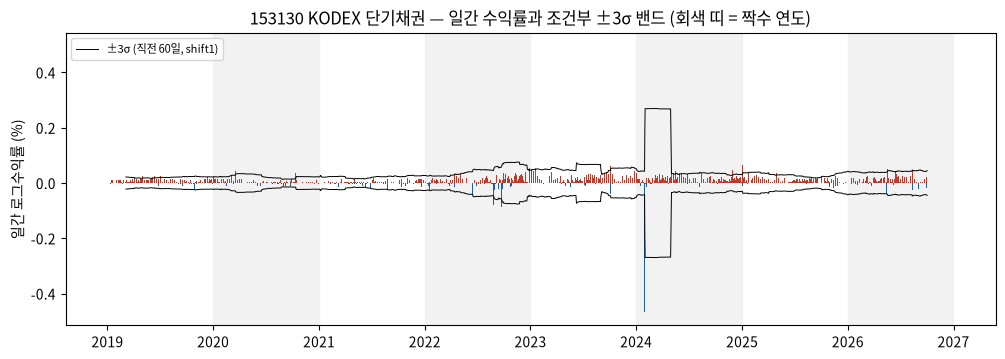

In [3]:
F.fig02_return_ts(c)

**WHAT THIS FIGURE MEASURES** — 막대 = 일간 로그수익률 (빨강 +, 파랑 −). 검은 선 = 직전 60일 표준편차 ×3 (shift(1), 당일 미포함). 회색 띠 = 짝수 연도.

**WHAT WE SEE** — 최대 상승 0.50% (2024-01-31), 최대 하락 -0.47% (2024-01-30). 변동성 최고 연도 2024 (0.7%), 최저 2019 (0.1%). 밴드 폭이 시기마다 달라 변동성 군집이 보인다.

**WHY IT MATTERS FINANCIALLY** — 고정 절대 threshold 대신 조건부(직전 변동성 대비) 기준을 써야 하는 근거다. 같은 −3% 도 저변동기에는 극단, 고변동기에는 평범하다.

**WHAT WE CANNOT CONCLUDE** — dq_flags.csv 가 2024-01-30, 2024-01-31 을 isolated_spike_reversal(다음날 되돌림) 후보로 표시한다. 이 날의 극단값이 기초자산 움직임인지 ETF 가격 괴리인지는 NAV 없이 구분할 수 없다. 초저변동(연 0.32%) + 틱 이산성(0수익률 비율 16.8%)으로 분모가 작아 robust-z·첨도가 폭발한다 (CL-25: −0.47% 가 rz −34). 통계적 극단 ≠ 경제적 충격.

## Fig 3. 수익률 분포 · Q-Q · 꼬리 생존함수

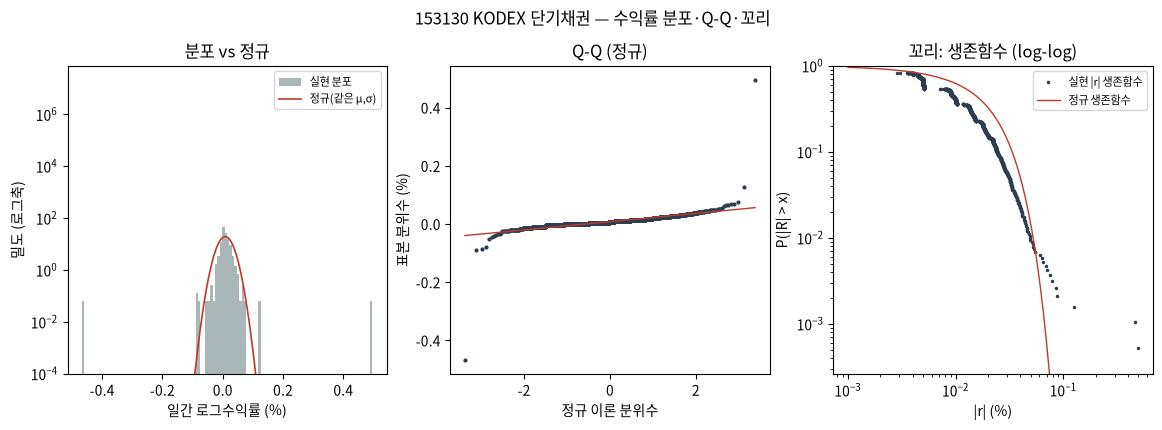

In [4]:
F.fig03_distribution(c)

**WHAT THIS FIGURE MEASURES** — 왼쪽: 히스토그램(로그 밀도) vs 같은 평균·표준편차의 정규. 가운데: 정규 Q-Q. 오른쪽: |r| 생존함수 P(|R|>x) log-log, 빨강 = 정규 기대치.

**WHAT WE SEE** — skew 0.62, excess kurtosis 323.8 → 상위 3일 제거 시 6.1. 일간 Q01 -0.02% / Q99 0.05%. Q-Q 양 끝이 직선에서 벗어나면 정규보다 두꺼운 꼬리.

**WHY IT MATTERS FINANCIALLY** — 첨도가 소수 날짜에 좌우되면 '이 자산은 원래 꼬리가 두껍다'가 아니라 '몇 날의 기억'이다. 리스크 지표(VaR 등)를 정규 가정으로 만들면 꼬리를 과소평가한다.

**WHAT WE CANNOT CONCLUDE** — 초저변동(연 0.32%) + 틱 이산성(0수익률 비율 16.8%)으로 분모가 작아 robust-z·첨도가 폭발한다 (CL-25: −0.47% 가 rz −34). 통계적 극단 ≠ 경제적 충격. dq_flags.csv 가 2024-01-30, 2024-01-31 을 isolated_spike_reversal(다음날 되돌림) 후보로 표시한다. 이 날의 극단값이 기초자산 움직임인지 ETF 가격 괴리인지는 NAV 없이 구분할 수 없다.

## Fig 4. rolling 변동성 (20/60일) 과 연도별 변동성

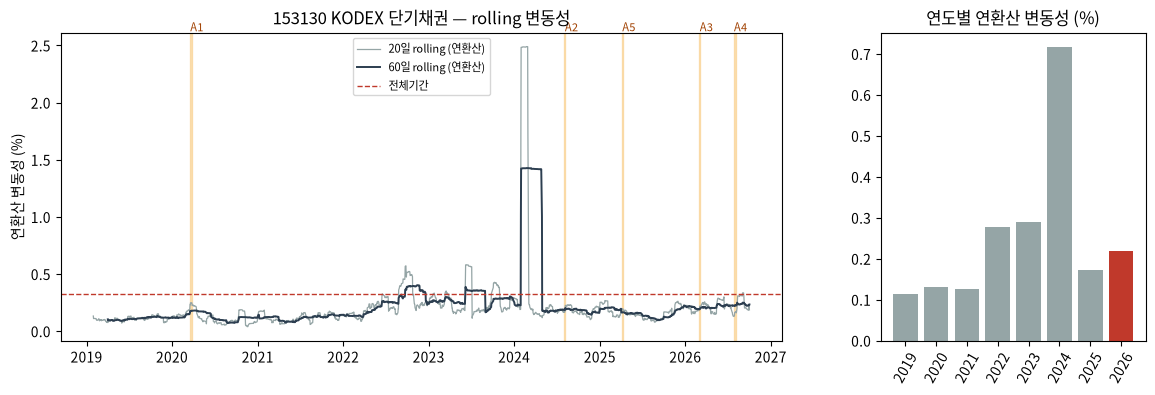

In [5]:
F.fig04_rolling_vol(c)

**WHAT THIS FIGURE MEASURES** — 왼쪽: 20일·60일 rolling std ×√252, 점선 = 전체기간. 오른쪽: 연도별 연환산 변동성 (빨강 = 2026).

**WHAT WE SEE** — 전체 0.3%, 2019-25 0.3%, 2026 0.2% → 비율 0.66×. 연도별: 2019 0%, 2020 0%, 2021 0%, 2022 0%, 2023 0%, 2024 1%, 2025 0%, 2026 0%.

**WHY IT MATTERS FINANCIALLY** — 변동성은 국면 변수다. 전체기간 평균으로 '평시'를 정의하면 2020·2026 같은 고변동 구간이 기준선을 끌어올린다. universe 비교에서는 2026 비율이 국내주식 국면을 가르는 축이다 (CL-30).

**WHAT WE CANNOT CONCLUDE** — 초저변동(연 0.32%) + 틱 이산성(0수익률 비율 16.8%)으로 분모가 작아 robust-z·첨도가 폭발한다 (CL-25: −0.47% 가 rz −34). 통계적 극단 ≠ 경제적 충격.

## Fig 5. 상위 낙폭 에피소드 (깊이 · 하락기간 · 회복기간)

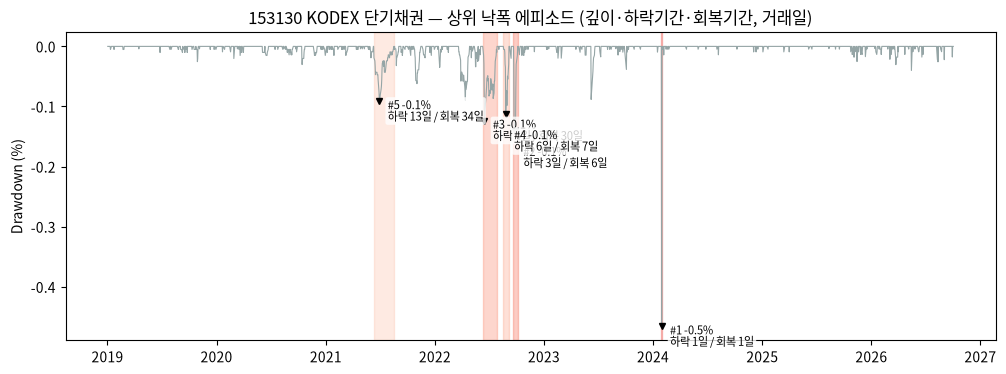

In [6]:
F.fig05_dd_episodes(c)

**WHAT THIS FIGURE MEASURES** — 회색 = 낙폭 곡선. 색 띠 = 깊이 상위 5개 에피소드의 고점→회복 구간 (미회복은 마지막 날까지). 주석 = 깊이·고점→저점 거래일·저점→회복 거래일.

**WHAT WE SEE** — #1 -0.5% (2024-01-29→2024-01-30, 하락 1일, 회복 1); #2 -0.1% (2022-09-21→2022-09-26, 하락 3일, 회복 6); #3 -0.1% (2022-06-10→2022-06-16, 하락 4일, 회복 30).

**WHY IT MATTERS FINANCIALLY** — 같은 깊이라도 회복기간이 다르면 위험의 성격이 다르다 (빠른 V자 vs 장기 레짐). 낙폭 에피소드는 이후 event window 와 regime 정의의 후보 구간을 준다.

**WHAT WE CANNOT CONCLUDE** — 기초지수 명칭이 '단기채 (추정: KIS 통안채/단기)' 로 추정 상태다. 지수 데이터가 없어 추적오차를 측정할 수 없고 benchmark 는 ETF proxy 다.

## Fig 6. 거래량 배수와 수익률–거래량 joint

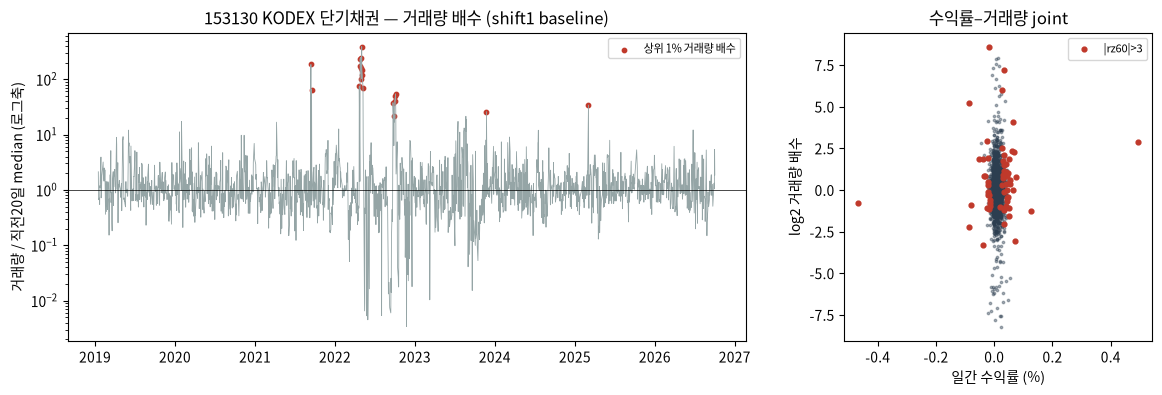

In [7]:
F.fig06_volume(c)

**WHAT THIS FIGURE MEASURES** — 왼쪽: 거래량 / 직전 20일 median (shift(1)) 로그축, 빨강 점 = 상위 1%. 오른쪽: x=일간 수익률, y=log2 거래량 배수, 빨강 = |rz60|>3.

**WHAT WE SEE** — 극단일 거래량 배수 median: − 극단 0.87×, + 극단 1.63× (전체 일 median 0.97×). corr(|r|, log 거래량배수) = 0.023. 거래량배수 Q99 = 21.4×.

**WHY IT MATTERS FINANCIALLY** — 가격 극단이 거래량 급증을 동반하는지(정보 충격/강제 매매)와 방향 비대칭(급락일 vs 급등일)은 CL-26 의 상품유형별 반대 패턴과 직접 연결된다.

**WHAT WE CANNOT CONCLUDE** — 거래량은 주 단위이며 거래대금·호가 깊이가 아니다. LP 호가 공급 변화나 기관 설정·환매가 거래량에 섞여 투자자 수요로 해석할 수 없다.

## Fig 7. benchmark 대비 동일일 산점도와 OLS

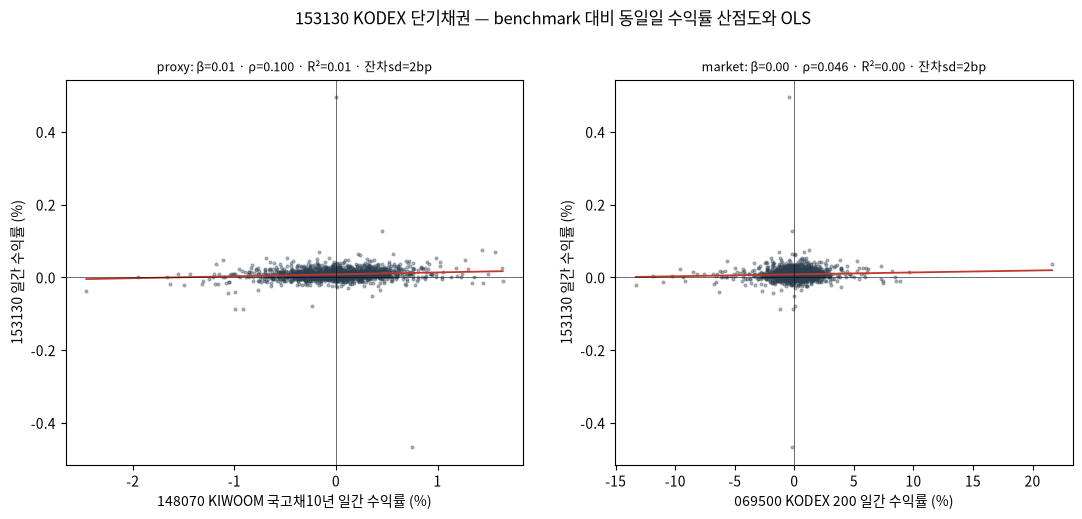

In [8]:
F.fig07_benchmark_scatter(c)

**WHAT THIS FIGURE MEASURES** — x = 비교 ETF 일간 수익률, y = 153130 일간 수익률, 빨강 = OLS 적합. 제목 = β, Pearson ρ, R², 잔차 표준편차(bp). 비교 ①proxy 148070 ②market 069500.

**WHAT WE SEE** — proxy 148070: β=0.01, ρ=0.100, Spearman=0.141, R²=0.01, 잔차sd=2bp. market 069500: β=0.00, ρ=0.046, Spearman=0.047, R²=0.00, 잔차sd=2bp.

**WHY IT MATTERS FINANCIALLY** — β 는 시장 1 움직임당 민감도, 잔차 sd 는 시장으로 설명되지 않는 고유 변동 크기다. 이상 탐지에서 '시장 공통분을 뺀 상대 움직임'을 쓸지 결정하는 기준이 된다.

**WHAT WE CANNOT CONCLUDE** — 기초지수 명칭이 '단기채 (추정: KIS 통안채/단기)' 로 추정 상태다. 지수 데이터가 없어 추적오차를 측정할 수 없고 benchmark 는 ETF proxy 다.

## Fig 8. rolling 120일 상관과 β

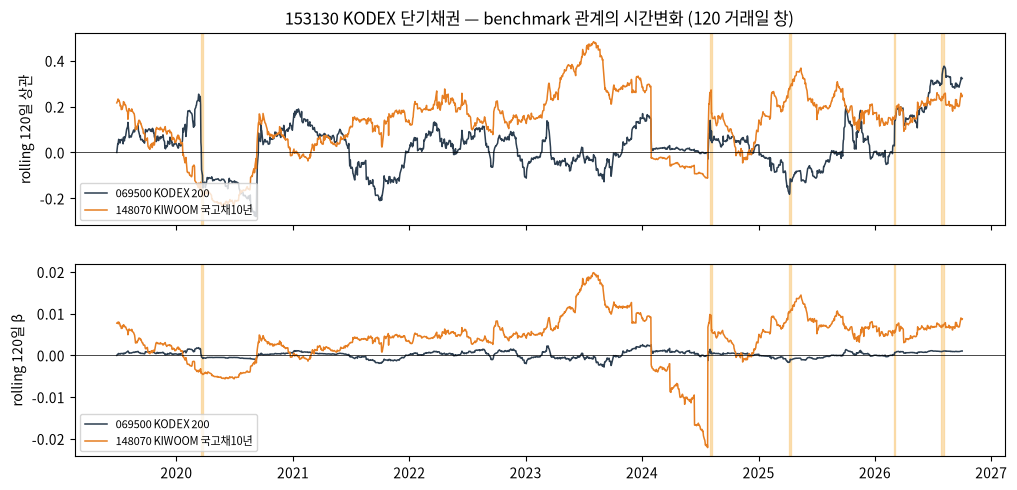

In [9]:
F.fig08_rolling_corr_beta(c)

**WHAT THIS FIGURE MEASURES** — 120 거래일 창의 Pearson 상관(위)과 β(아래). 검정 = market 069500, 주황 = proxy 148070 (같으면 하나만). 주황 띠 = anchor.

**WHAT WE SEE** — market 상관 범위 -0.28 (2020-09-07) ~ 0.38 (2026-08-06). 하위기간 상관: 2019-21 -0.029 vs 2022-26 0.057.

**WHY IT MATTERS FINANCIALLY** — 관계 자체가 시간변화하는 상태 변수다. 충격기에 상관이 수렴하면 분산효과가 필요할 때 사라지고, 부호가 바뀌면 '헤지 자산' 라벨이 국면 한정이 된다.

**WHAT WE CANNOT CONCLUDE** — universe.csv structural_notes: [OBS] Category=6. 극저변동성·거의 단조 증가 → 변동성 분모 지표(z-score, Sharpe, 상관) 왜곡, 틱사이즈 영향 [ANA]

## Fig 9. market reference (069500) 대비 누적 상대수익

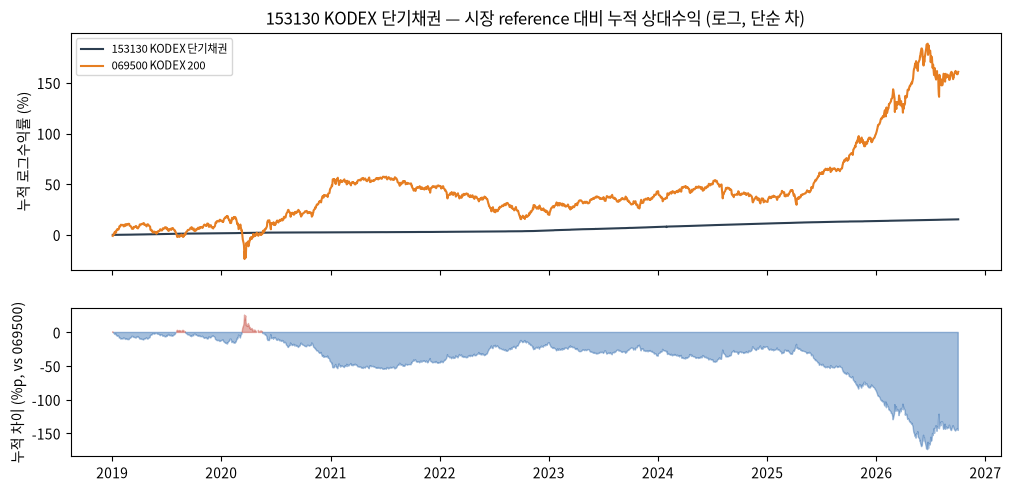

In [10]:
F.fig09_relative(c)

**WHAT THIS FIGURE MEASURES** — 위: 본 ETF 와 069500 의 누적 로그수익률. 아래: 누적 차이 Σ(r − r_market) %p (빨강 = 앞섬, 파랑 = 뒤처짐). β 조정 없음.

**WHAT WE SEE** — 본 ETF 누적 15.4%, 누적 차이 -145.5%p (β 조정 없는 단순 차).

**WHY IT MATTERS FINANCIALLY** — 상대수익이 장기 추세를 가지면 시장 factor 외 고유 factor(업종·자산군·통화)가 존재한다는 뜻이고, 이상 탐지 시 '시장 대비 초과' 정의의 기준선을 준다.

**WHAT WE CANNOT CONCLUDE** — 초저변동(연 0.32%) + 틱 이산성(0수익률 비율 16.8%)으로 분모가 작아 robust-z·첨도가 폭발한다 (CL-25: −0.47% 가 rz −34). 통계적 극단 ≠ 경제적 충격.

## Fig 10. robust-z 극단일 타임라인 (+/− 분리)

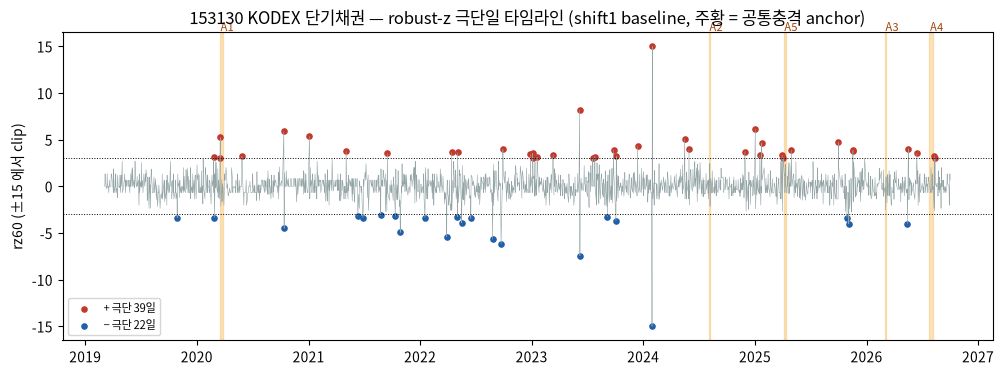

In [11]:
F.fig10_extreme_timeline(c)

**WHAT THIS FIGURE MEASURES** — rz60 = (r − 직전60일 median)/(1.4826·직전60일 MAD), shift(1) 로 당일 미포함. 점선 = ±3. 빨강 = + 극단, 파랑 = − 극단, 주황 띠 = 공통충격 anchor. 표시는 ±15 에서 clip.

**WHAT WE SEE** — |rz60|>3: + 39일 / − 22일. 상위 |rz| 5일: 2024-01-31 +0.50% (rz +35.8); 2024-01-30 -0.47% (rz -34.2); 2023-06-07 +0.13% (rz +8.2); 2023-06-08 -0.09% (rz -7.4); 2022-09-23 -0.09% (rz -6.2).

**WHY IT MATTERS FINANCIALLY** — +/− 극단을 분리해야 급등·급락의 빈도·군집이 다르다는 점이 보인다. anchor 와 겹치는 극단은 공통충격, 겹치지 않는 극단은 고유충격 후보다.

**WHAT WE CANNOT CONCLUDE** — 초저변동(연 0.32%) + 틱 이산성(0수익률 비율 16.8%)으로 분모가 작아 robust-z·첨도가 폭발한다 (CL-25: −0.47% 가 rz −34). 통계적 극단 ≠ 경제적 충격. dq_flags.csv 가 2024-01-30, 2024-01-31 을 isolated_spike_reversal(다음날 되돌림) 후보로 표시한다. 이 날의 극단값이 기초자산 움직임인지 ETF 가격 괴리인지는 NAV 없이 구분할 수 없다.

## Fig 11. 공통충격 anchor 전후 경로

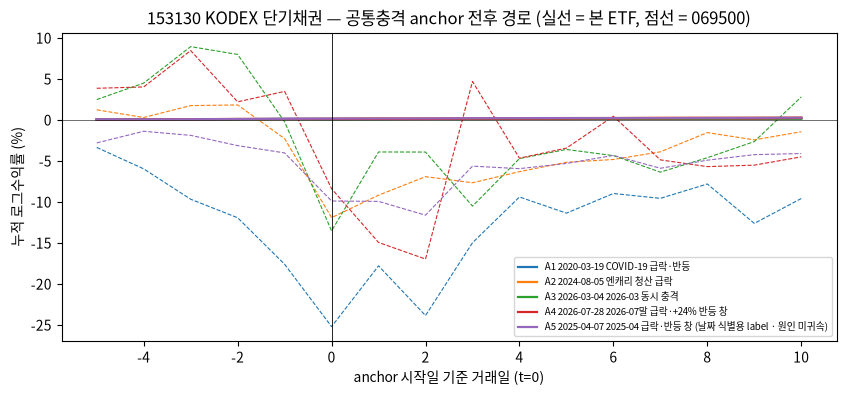

In [12]:
F.fig11_event_window(c)

**WHAT THIS FIGURE MEASURES** — 각 anchor 시작일 t=0 기준 −5~+10 거래일 누적 로그수익률. 실선 = 본 ETF, 점선 = 069500. anchor 정의는 config/event_anchors.csv.

**WHAT WE SEE** — anchor 구간(시작~끝) 누적 수익률: A1 +0.0%, A2 +0.0%, A3 -0.0%, A4 +0.0%, A5 +0.1%.

**WHY IT MATTERS FINANCIALLY** — 공통충격에 대한 반응 방향·크기·회복 속도가 상품군 정체성(동반 하락, 반대 방향, 무관)을 가장 직접적으로 보여준다 (CL-22/27).

**WHAT WE CANNOT CONCLUDE** — anchor 5개는 표본이 작아 평균 반응을 일반화할 수 없다. A4(2026-07-28~08-03)는 universe 공통이 아니라 국내 주식 국면 충격이다 (CL-24). A5(2025-04-07~10)는 FRAGILE anchor 다 — rz3·abs3 에서는 생존하나 ETF별 q99 정의에서 탈락 (CL-33). anchor 라벨은 날짜 식별용이며 원인(뉴스)을 귀속하지 않는다.

## 결론 ↔ 지지 figure
| # | 결론 (OBSERVATION) | 지지 figure | 근거 수치 |
|---|---|---|---|
| 1 | 평소 변동성 규모는 연 0.3%, 2026 은 2019-25 대비 0.66× | Fig 4, Fig 2 | vol_2026 0.2% |
| 2 | 꼬리 두께 중 소수 날짜 기여 = kurt 323.8 → trim3 6.1 | Fig 3 | Q01/Q99 -0.02%/0.05% |
| 3 | 시장(069500) 민감도 β=0.00, ρ=0.046; proxy(148070) β=0.01, ρ=0.100 | Fig 7 | 잔차sd 2bp |
| 4 | 시장 관계는 시간변화: 120일 상관 -0.28~0.38, 2019-21 -0.03 vs 2022-26 0.06 | Fig 8 | — |
| 5 | 최대낙폭 -0.5% (2024-01-30), 회복 2024-01-31 | Fig 1, Fig 5 | — |
| 6 | 극단일(|rz60|>3) + 39 / − 22, 정의 민감 | Fig 10 | top: 2024-01-31 |
| 7 | 공통충격 반응: A1 +0.0%, A2 +0.0%, A3 -0.0%, A4 +0.0%, A5 +0.1% | Fig 11 | — |
| 8 | 시장 대비 누적 차이 -145.5%p (β 미조정) | Fig 9 | — |
| 9 | 극단일 거래량 배수 −0.87× / +1.63× vs 전체 0.97× | Fig 6 | — |

**이 notebook 이 주장하지 않는 것**: 인과(왜 움직였는가), 예측, 매매 신호. 모든 관계는 동일일 통계적 동행이다.

**ETF별 한계 요약**: - dq_flags.csv 가 2024-01-30, 2024-01-31 을 isolated_spike_reversal(다음날 되돌림) 후보로 표시한다. 이 날의 극단값이 기초자산 움직임인지 ETF 가격 괴리인지는 NAV 없이 구분할 수 없다. - 기초지수 명칭이 '단기채 (추정: KIS 통안채/단기)' 로 추정 상태다. 지수 데이터가 없어 추적오차를 측정할 수 없고 benchmark 는 ETF proxy 다. - 초저변동(연 0.32%) + 틱 이산성(0수익률 비율 16.8%)으로 분모가 작아 robust-z·첨도가 폭발한다 (CL-25: −0.47% 가 rz −34). 통계적 극단 ≠ 경제적 충격. - universe.csv structural_notes: [OBS] Category=6. 극저변동성·거의 단조 증가 → 변동성 분모 지표(z-score, Sharpe, 상관) 왜곡, 틱사이즈 영향 [ANA]